# Lab 2: Voltage Dividers

<span style="background-color:yellow">
Cole Stevens
</span>

## Voltage Divider: Automated Data Taking
Imagine you have built several different voltage dividers and wanted to characterize them. It might be nice to automate the task of varying the input voltage and measuring the output voltage.

### Voltage Divider Circuit (Breadboard)
* In AHA 2_2, you constructed a voltage divider circuit on your breadboard, and drew a diagram for how to connect it to the devices on your benchtop.  Go ahead and connect your breadboard per your diagram. You will need to choose $V_\text{in}$.  What values of $R_{1}$ and $R_{2}$ did you choose?
* Make manual meaurements using your DMM and be sure your setup works like you expect.  Do you measure the correct ratio of input/output voltages?

<span style="background-color:yellow">
$$R_\text{1} = 992 \ohm , R_\text{2} = 99.7 \ohm$$
</span>

<span style="background-color:yellow">
For V_\text{in} = 1 V, V_\text{out} = 0.091 V. For V_\text{in} = 2 V, V_\text{out} = 0.183 V. The ratio of input/output voltages is correct.
</span>

### Automate the Voltage Divider Testing
Previously you learned to use a loop to a) control the output of power supply and b) read the signal from a DMM.

Now you are in a position to automate the process of varying the input voltage and reading the output voltage.  This will consist of several steps:

* Determine that the computer can see the instruments and find their relevant addresses. (Recall that you will need the PyVisa library which can be loaded with `import pyvisa`.)
* Check that you can set the output voltage from the power supply, which becomes the input voltage to your divider.
* Check that you can read the signal from the DMM.
* Now write some lines of Python code creating a loop that will 
    * vary the input voltage (over the range 0-8 V) and 
    * measure the corresponding output voltage. 
    * You should plot your data with a labeled graph having $V_\text{out}$ on the vertical axis and $V_\text{in}$ on the horizontal axis.  (Recall that you will need the usual libraries so as always inlcude these lines: `import matplotlib.pyplot as plt`, `import numpy as np`, and `import pandas as pd`.)

### EXERCISE: Automated Voltage divider program
Put your Python program in the cell below and run it.  The output should be a plot.  

In [1]:
import matplotlib.pyplot as plt
import numpy as np               
import scipy as sp
import pyvisa                    
import pandas as pd

In [2]:
rm = pyvisa.ResourceManager()
rm.list_resources()

('ASRL2::INSTR',
 'GPIB0::10::INSTR',
 'GPIB0::22::INSTR',
 'GPIB0::5::INSTR',
 'USB0::0x0957::0x179B::MY52498198::0::INSTR')

In [4]:
dmm = rm.open_resource('GPIB0::22::INSTR')
print(dmm.query("*IDN?"))
ps = rm.open_resource('GPIB0::5::INSTR')
print(ps.query("*IDN?"))

HEWLETT-PACKARD,34401A,0,11-5-2

Agilent Technologies,E3646A,0,1.7-5.0-1.0



In [5]:
ps.write("APPL 2.3")


10

In [12]:
testvoltage = dmm.query("MEAS:VOLT:DC?")
print('V = ',testvoltage)

V =  +2.10164160E-01



In [22]:
# put your program to "characterize" a voltage divider below
voltin = np.linspace(0, 8, 20)
voltout = []
dmm.write('*RST')
for setvoltage in voltin:
    voltagestr = "APPL " + str(setvoltage) + ", 1.0"
    ps.write(voltagestr)
    voltoutstr = dmm.query("MEAS:VOLT:DC?", 1)
    voltout.append(float(voltoutstr))
print(voltin)
print(voltout)
    

[0.         0.42105263 0.84210526 1.26315789 1.68421053 2.10526316
 2.52631579 2.94736842 3.36842105 3.78947368 4.21052632 4.63157895
 5.05263158 5.47368421 5.89473684 6.31578947 6.73684211 7.15789474
 7.57894737 8.        ]
[0.000137578, 0.038577263, 0.077027382, 0.11547958, 0.15389687, 0.19235146, 0.23079405, 0.26923264, 0.30768973, 0.34613404, 0.38460769, 0.42306331, 0.4614804, 0.49991728, 0.53841311, 0.57686132, 0.61530947, 0.65375665, 0.69220978, 0.73064171]


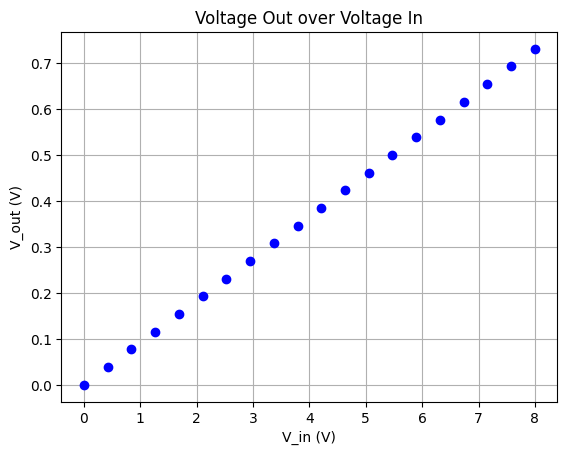

In [56]:
plt.plot(voltin, voltout, 'bo')
plt.xlabel('V_in (V)')
plt.ylabel('V_out (V)')
plt.title('Voltage Out over Voltage In')
plt.grid(True)
plt.savefig('V_out__V_in.png')

In [24]:
df = []
df = pd.DataFrame(voltin)
df.to_csv('lab2_voltagein_23Jan2026.csv', index = False)

df = []
df = pd.DataFrame(voltout)
df.to_csv('lab1_voltageout_23Jan2026.csv', index = False)

In [26]:
results = sp.stats.linregress(voltin,voltout)
print('slope = ',results.slope,' +/- ',results.stderr)
print('intercept = ',results.intercept,' +/- ',results.intercept_stderr)

slope =  0.09131592586964284  +/-  1.6109905066352338e-06
intercept =  0.00011536217142865679  +/-  7.5381165160697964e-06


Is $V_\text{out}/V_\text{in}$ from your automated voltage divider characterization what you expect?  
<br>
<span style="background-color:yellow">
Yes. The $V_\text{out}/V_\text{in}$ ratio I got from manually measuring was 0.091 V. From the graph the $V_\text{out}/V_\text{in}$ ratio can be extrapolated by calculating the line of best fit and using the slope. The slope of the line of best fit is 0.0913, which is very close to the ratio I was expecting.
</span>

## Getting data from the keyboard
In many cases you will want to get data from the keyboard (the label for a sample, a filename for storing data, value of experimental parameter, etc.). This can be done using the `input('your words here')` command. Your program will wait until something is entered from the keyboard. The result of using the `input` command is to store the response as *text* (even if the user enters a number). 

**Strings vs. Real numbers**

Computer languages distinguish between different types of data, in particular we are interested in text and numbers.
* *text*, referrred to as a **string** which can you display or manipulate 
* *numbers*, referred to as a **real** (for real number) or **float** (for floating point number) that you can do mathematics with

The next cell shows how to get the user's name and then respond. Give it a try.

In [28]:
yourname = input('What is your name?')
print('Nice to meet you', yourname)

What is your name? Cole


Nice to meet you Cole


Now let's get the user's age, then output double the age.

In [30]:
yourage = input('What is your age?')
print('I see that you are', yourage)
doubleage = 2*yourage
print('Double your age is', doubleage)

What is your age? ab


I see that you are ab
Double your age is abab


**Whoa!!!** What happened here? 

Because the "23" that was input is treated as text (a **string**), doubling it takes the literal string and repeats it.  The computer does not *know* that 23 is a number.  Go back and rerun the cell and put in "ab" (without the quotes) for your age and see what happens.

What we really want is to turn the input string into a number that we can use with mathematical operations.  This can be done using the `float( )` command.  This takes a string that represents a number and changes it into a real number that can be used in math.

In [31]:
yourage = input('What is your age?')
print('I see that you are', yourage)

doubleage = 2*float(yourage)

print('Double your age is', doubleage)

What is your age? 22


I see that you are 22
Double your age is 44.0


### EXERCISE: Inputting from keyboard
Write appropriate Python commands to 
* get a person's name, 
* their birth year, and
* calculate and output their age in years as: *Hello xxxx, you are xx years old.*

Put your program in the cell below.

In [32]:
# code for keyboard input of name and then birth year; calculate then output age in years
yourname = input('What is your name?')
yourbirthyr = input('What is your birthyear?')
yourage = 2026 - float(yourbirthyr)
print('Hello', yourname, ', you are', yourage, 'years old.')


What is your name? Cole
What is your birthyear? 2003


Hello Cole , you are 23.0 years old.


## Repeat some commands using a `for` loop
Suppose you want to get the ages of several people.  Repeating the same set of steps can be done using a control structure called a `for` loop.  (There are other control structures such as `while`.)  The syntax is `for i in range(start, stop):`, where `i` is a "dummy" variable, `start` is the beginning value and `stop-1` is the ending value.  Note that the `for` line ends with a colon. **The commands that you want repeated must be indented once relative to the initial `for` command.**

Here is an example:

In [35]:
for j in range(0,4):
    print(j)


0
1
2
3


Note that the sequence of numbers created by `range`:
* the commands to be executed are indented
* start with zero
* go up to *one less* then ending number

### EXERCISE
In the cell below, write code using a `for` loop that will ask the user for the names and ages of a group (family?, roommate?, lab partners?).  Make a list object that contains the names and ages.

In [48]:
# # code for keyboard input of names, ages and output of lists
familynames = list()
familysize = input('How many family members do you have?')
size = int(familysize) + 1
for blank in range(1, size):
    names = input('What is your ' + str(blank) + ' family member`s name?')
    familynames.append(str(names))
print('Your family members` names are', familynames)

How many family members do you have? 5
What is your 1 family member`s name? Henry
What is your 2 family member`s name? David
What is your 3 family member`s name? Thoreau
What is your 4 family member`s name? Jean
What is your 5 family member`s name? Paul


Your family members` names are ['Henry', 'David', 'Thoreau', 'Jean', 'Paul']


In [47]:
familyages = list()
size = int(familysize) + 1
for blank in range(1, size):
    age = input('What year was your ' + str(blank) + ' family member born?')
    memberage = 2026 - float(age)
    familyages.append(str(memberage))
print('Your family members are', familyages, 'years old')

What year was your 1 family member born? 1978
What year was your 2 family member born? 1979
What year was your 3 family member born? 2004
What year was your 4 family member born? 2007
What year was your 5 family member born? 2011


Your family members are ['48.0', '47.0', '22.0', '19.0', '15.0'] years old


## LABORATORY - Voltage divider with load (computer assisted)

Now we can explore the limiting behavior of a voltage divider circuit with a load.

### Make a plot of $\frac{V_\text{out}}{V_\text{in}}$ vs. $R_\text{load}$

To do this, use your breadboard with voltage divider circuit and now include a variable load resistance.  This can be readily done using a **decade resistance box**. This is a device that lets you select the specific resistance you want. We will set $V_\text{in}$, then the load and measure $V_\text{out}$.

Here is a plan:
* Set your power supply at a specific value of $V_\text{in}$.
* Pick $R_1$ and $R_2$ for your voltage divider and leave them fixed for now.
* Connect a decade resistance box as the load and set a particular $R_\text{load}$. 
* Enter, using the keyboard, the value of $R_\text{load}$. 
* Read the DMM to find the corresponding $V_\text{out}$.
* Using a loop, repeat the above steps for several other values of $R_\text{load}$.

You can do this by modifying your earlier program to 
* Include keyboard input for each $R_\text{load}$.
* Create a set of arrays corresponding to $R_\text{load}$, and $V_\text{out}$.
* Plot $\frac{V_\text{out}}{V_\text{in}}$ vs. $R_\text{load}$. (Recall that you will need the usual libraries so as always include these lines (if you haven't already): `import matplotlib.pyplot as plt`, `import numpy as np`, and `import pandas as pd`.  Be sure to save your data and plots in case you need them later.

**Note** that you will want to choose values for $R_\text{load}$ such that the predicted limiting behavior of $\frac{V_\text{out}}{V_\text{in}}$ is shown on your plot of $\frac{V_\text{out}}{V_\text{in}}$ versus $R_\text{load}$.  Depending on your choice, it may be useful to consider plotting with `plt.semilogx()`.

Put your program in the cell below and run it.

In [81]:
np.geomspace(10,10000000,15)

array([1.00000000e+01, 2.68269580e+01, 7.19685673e+01, 1.93069773e+02,
       5.17947468e+02, 1.38949549e+03, 3.72759372e+03, 1.00000000e+04,
       2.68269580e+04, 7.19685673e+04, 1.93069773e+05, 5.17947468e+05,
       1.38949549e+06, 3.72759372e+06, 1.00000000e+07])

In [34]:
# program for looking at limiting behavior of voltage divider with load
Vin = 1
Vout = []
dmm.write('*RST')
Rload = list()
Rloadrange = input('How many Rload values do you want?')
size = int(Rloadrange) + 1
for blank in range(1, size):
    Rinput = input('What is your ' + str(blank) + ' Rload input?')
    Rload.append(float(Rinput))
    voltoutstr = dmm.query("MEAS:VOLT:DC?", 1)
    Vout.append(float(voltoutstr))
print('Your Rload inputs are', Rload)
print('Your Vout outputs are', Vout)

How many Rload values do you want? 15
What is your 1 Rload input? 10
What is your 2 Rload input? 30
What is your 3 Rload input? 80
What is your 4 Rload input? 200
What is your 5 Rload input? 500
What is your 6 Rload input? 1400
What is your 7 Rload input? 3800
What is your 8 Rload input? 10000
What is your 9 Rload input? 27000
What is your 10 Rload input? 72000
What is your 11 Rload input? 190000
What is your 12 Rload input? 520000
What is your 13 Rload input? 1400000
What is your 14 Rload input? 3700000
What is your 15 Rload input? 10000000


Your Rload inputs are [10.0, 30.0, 80.0, 200.0, 500.0, 1400.0, 3800.0, 10000.0, 27000.0, 72000.0, 190000.0, 520000.0, 1400000.0, 3700000.0, 10000000.0]
Your Vout outputs are [0.009293063, 0.022851217, 0.042914646, 0.062895656, 0.07724404, 0.085660459, 0.08907707, 0.090381498, 0.09089283, 0.091083245, 0.09115686, 0.091182855, 0.09119342, 0.091196697, 0.09119722]


In [35]:
loadresistance = np.array(Rload)
voltageout = np.array(Vout)
print(loadresistance)
print(voltageout)

[1.0e+01 3.0e+01 8.0e+01 2.0e+02 5.0e+02 1.4e+03 3.8e+03 1.0e+04 2.7e+04
 7.2e+04 1.9e+05 5.2e+05 1.4e+06 3.7e+06 1.0e+07]
[0.00929306 0.02285122 0.04291465 0.06289566 0.07724404 0.08566046
 0.08907707 0.0903815  0.09089283 0.09108324 0.09115686 0.09118285
 0.09119342 0.0911967  0.09119722]


In [38]:
df = []
df = pd.DataFrame(loadresistance)
df.to_csv('lab2_loadresistance_26Jan2026.csv', index = False)

df = []
df = pd.DataFrame(voltageout)
df.to_csv('lab2_voltageout_load_26Jan2026.csv', index = False)

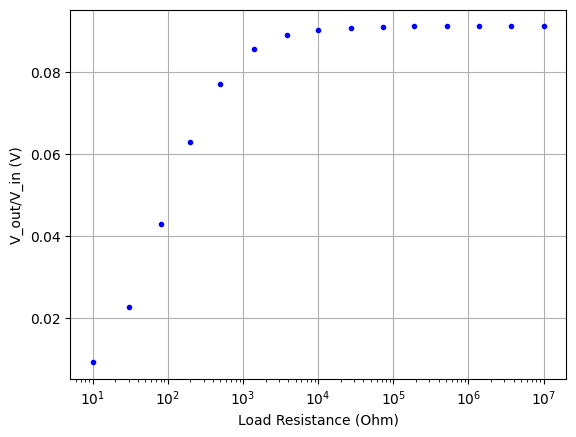

In [39]:
#plt.plot(loadresistance, voltageout, 'bo')
plt.semilogx(loadresistance, voltageout, 'b.')
plt.xlabel('Load Resistance (Ohm)')
plt.ylabel('V_out/V_in (V)')
#plt.ylim(0,1)
plt.grid(True)
plt.savefig('Vout&Vin_Load_Resistance.png')

### Check your results

Your plot above of $V_\text{out}/V_\text{in}$ vs $R_\text{load}$ should look like what we predicted in lecture.  Show that behavior for $R_\text{load}\rightarrow 0$ and $R_\text{load} \rightarrow \infty$ are quantitatively as expected.

In [ ]:
############## calculations go here

## Bonus:  Why was our lightbulb data in Lab 1 so strange?

If you recall, your I-V measurements for a small lightbulb in Lab 1 resulted a plot that had some anomalous data.  Changing the direction in which you took your measurements did improve the data:

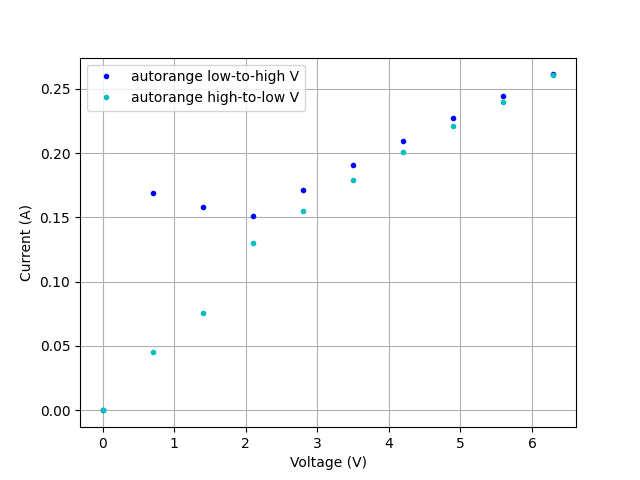

Adding a time delay, however, did not remove the anomaly.  What was going on?

You may have noticed that while you were taking measurements, the DMM makes a clicking noise.  This is the DMM automatically changing its measurement range, and the anomalous data in your lightbulb I-V curve was -- at least in part -- a result of the autorange behaving in a way that altered our data.

To fix this we want to code the DMM's ranging function to a set value rather than letting it autorange.  We do this by altering our SCPIww code(Standard Commands for Programmable Instruments, pronounced "skippy").  Some syntax options are given on page 62 of the DMM's manual here (https://www.keysight.com/us/en/assets/9018-01063/user-manuals/9018-01063.pdf), with options for the $<range>$ parameter given on page 48 here (https://int.siglent.com/upload_file/user/SDM3065X/SDM3065X_Remote_Manual_RC06036-E01A.pdf).

The takeaway is that when we measure current within our I-V measurement loop, we need to change 

`readcurrentstr = dmm.query("MEAS:CURR:DC?", 1)`

to

`readcurrentstr = dmm.query("MEAS:CURR:DC? .2", 1)`.

The `.2` means that we are setting the current measurement range to $0.2\;A$, or $200\;mA$.  Because it is the first argument after the `?`, it refers to the $<range>$ as opposed to the $<resolution>$.  We are choosing $0.2\;A$ (as opposed to the other options available) because our data is roughly that order of magnitude.

Go ahead and build your circuit to measure the I-V curve of a type 46 lightbulb.  Write code to produce two overlayed I-V curves:  one in which you allow the DMM to autorange, and the other in which you have set the range to $0.2\;A$.  Take 50-100 points for each curve so that you can see the behavior well.  (If you'd like to experiment with different ranges, you can go ahead and do that too.)

In [ ]:
#produce two overlayed I-V curves:  one with autorange, the other with a range set to 0.2 A
#
#
#

1.  Do these results make sense given the low-to-high V versus high-to-low V measurements you took in Lab 1?  Why or why not?

<span style="background-color:yellow">
Student response
</span>

Let's take a look at the "good" data you just took.  The curve still looks slightly anomalous; there appears to be a discontinuity in the derivative between $0\;V$ and $1\;V$.  Now that we have the range issue settled, we can return to adding a time delay to each measurement.  The resistance of some materials can change when current heats them up.  This is a common phenomenon in incandescent lightbulb filaments, so adding a time delay could change our measured currents.

Go ahead and write code below to produce two overlayed I-V curves:  one with no time delay, and one with a $2\;s$ delay.  Both measurements should have a set range of $0.2\;A$.  Take 50-100 data points so that you can characterize the curves well.  (If you'd like to include other values for time delays, feel free.)

In [ ]:
#produce two overlayed I-V curves:  one with a time delay of 2s, one with no time delay.  
#All measurements have a range set to 0.2 A.
#
#
#

2.  Explain why adding a time delay smoothes your I-V curve.  What is the time scale at which the filament heats and comes to equilibrium?

<span style="background-color:yellow">
Student response
</span>

**There are some important takeaways here.**

First, troubleshooting a system which has multiple simultaneous issues can be tricky.  We thought we had an initial fix by taking high-to-low voltage measurements, but this wasn't really a fix at all -- we were working *around* the problem rather than actually fixing it by improving our instrument control.  To troubleshoot a problem effectively, you need to understand what the problem is.

Next, our initial troubleshoot in Lab 1 implied that adding a time delay didn't have an effect on the data and wasn't a fix. In reality, adding a time delay *was* necessary to fix our data, but it was masked by the larger issue of ranging.  It is common in experimental setups to see what in principle are independent parameters affect each other.  When troubleshooting, change one parameter at a time, and take note of what values your constant parameters are.

Lastly, note that problems can occur because of your measurement system (your setup or instrumentation), or because of physics.  In this scenario, we had a problem with our measurement system (we needed to control the range), and we also had a physical problem (resistance varies with temperature in an incandescent filament).  When troubleshooting, it's important to think through how your measurements are being taken and how the measurement system is interacting with the physics you're trying to measure.